# Tune $D_{sei}$ to get SEI quality for different formation protocols

2025/04/16

The plan:
1. Define an objective function as some combination of expansion error and voltage error
1. Sweep through different values of D_sei for VC only (just start with VC for now)
1. Plot D_sei vs error function for the three different formation protocols

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from scipy.interpolate import interp1d

%load_ext autoreload
%matplotlib widget

plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [2]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'

        hr_max = 20*24

    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'

        hr_max = 20*24

    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'

        hr_max = 20*24

    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'

        hr_max = 20*24


    return file_arbin_list, daq_channel, hr_max


In [3]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2])

    file_arbin_list, daq_channel, hr_max = fetch_file_list(cellid)


    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    qq = df_arbin['Charge Capacity (Ah)']
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.nan
    y_current.iloc[np.where(tv/3600 > hr_max)] = np.nan

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.nan

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    y_strain.iloc[np.where(tt/3600 > hr_max)] = np.nan

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out


# Load the experimental data

In [4]:
expt1 = fetch_experimental_data(152064)
expt2 = fetch_experimental_data(152074)
expt3 = fetch_experimental_data(152071, 16)
expt4 = fetch_experimental_data(152098, 7)

/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_80690/1208438708.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.nan
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_80690/1208438708.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_current.iloc[np.where(tv/3600 > hr_max)] = np.nan
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_80690/1208438708.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [5]:
def run_sim(type, diff_ec, diff_vc, gamma_kappa=3000):
    """
    Run simulation for a given formation type and target EC diffusivity

    Arguments:
    ----------
    type: 'base', 'fast', 'fast+'
    diff_ec: target EC diffusivity, e.g., 4.2e-20 [m2/s]
    diff_vc: target VC diffusivity, e.g., 6.6e-18 [m2/s]

    Returns:
    ----------

    df_sim: DataFrame with simulation results
    """

    cell = cellsim.Cell()
    cell.load_config('params/default.yaml')

    # Update EC diffusivity
    cell.D_SEI11 = diff_ec
    cell.D_SEI21 = diff_ec

    # Update VC diffusivity
    cell.D_SEI12 = diff_vc
    cell.D_SEI22 = diff_vc

    # Update the GAMMA_KAPPA parameter
    cell.GAMMA_KAPPA = gamma_kappa

    if type == 'base':
        sim = cellsim.Simulation(cell, 80*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(2, -2.5/10, -2.5/10, 3.0)
        sim.run_chg_cccv(3, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(3, -2.5/10, -2.5/10, 3.0)
        sim.run_chg_cccv(4, 2.5/10, 2.5/20, 4.2)
        sim.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
        sim.run_rest(4, rest_time_hrs=6)

    elif type == 'fast':
        sim = cellsim.Simulation(cell, 20*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 2.5, 2.5, 3.9)
        sim.run_chg_cccv(2, 2.5/5, 0.125, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(2, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_chg_cccv(3, 2.5/5, 0.125, 4.2)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_dch_cccv(3, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_chg_cccv(4, 2.5/5, 0.125, 4.2)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_dch_cccv(4, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_chg_cccv(5, 2.5/5, 0.125, 4.2)
        sim.run_rest(5, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -2.5/5, 2.5/5, 3.9)
        sim.run_rest(5, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -2.5/1, 0.05, 3.0)
        sim.run_rest(6, rest_time_hrs=3)

    elif type == 'fast+':
        sim = cellsim.Simulation(cell, 10*3600)
        sim.run_rest(1, rest_time_hrs=0.5)
        sim.run_chg_cccv(2, 5.0, 5.0, 3.9)
        sim.run_chg_cccv(2, 2.5, 0.125, 4.2)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_dch_cccv(2, -2.5, 2.5, 3.9)
        sim.run_rest(2, rest_time_hrs=1/6)
        sim.run_chg_cccv(3, 2.5, 0.125, 4.2)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_dch_cccv(3, -2.5, 2.5, 3.9)
        sim.run_rest(3, rest_time_hrs=1/6)
        sim.run_chg_cccv(4, 2.5, 0.125, 4.2)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_dch_cccv(4, -2.5, 2.5, 3.9)
        sim.run_rest(4, rest_time_hrs=1/6)
        sim.run_chg_cccv(5, 2.5, 2.5, 4.2)
        sim.run_rest(5, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -2.5, 2.5, 3.9)
        sim.run_rest(6, rest_time_hrs=1/6)
        sim.run_dch_cccv(5, -5.0, 0.05, 3.0)
        sim.run_rest(6, rest_time_hrs=3)

    return sim.get_results()


In [6]:
def calculate_rmse(t_meas, y_meas, t_modl, y_modl,
                   to_plot=False):
    """
    Calculates RMSE error between model and measured data.

    Does not assume measurement vectors are the same size.

    Interpolates the measured data along the model vector

    Parameters:
    ----------
    t_meas: time vector for measured data
    y_meas: measured data
    t_modl: time vector for model data
    y_modl: model data
    to_plot: if True, plots the model and measured data

    Returns:
    ----------
    rmse: root mean square error between model and measured data
    """

    # Create interpolation function for voltage data
    f = interp1d(t_meas, y_meas, bounds_error=False, fill_value=np.nan)

    # Interpolate voltage onto model time points
    y_meas_interp = f(t_modl)

    squared_error = (y_modl - y_meas_interp)**2

    # Compute RMSE between model and measured voltage
    rmse = np.sqrt(np.nanmean(squared_error))

    if to_plot:

        plt.figure()
        plt.plot(t_modl, y_modl, label='Model')
        plt.plot(t_meas, y_meas, label='Measurement')
        plt.plot(t_modl, y_meas_interp, label='Interpolated Measurement', linestyle='--')
        plt.xlabel('t')
        plt.ylabel('y')
        plt.legend()
        plt.show()

    return rmse, t_modl, np.sqrt(squared_error)


In [7]:
diff_ec = 4.2e-20
diff_vc = 6.6e-18 # For VC

kappa_gamma = 4800
# kappa_gamma = 816

df_sim1 = run_sim('base', diff_ec, diff_vc, kappa_gamma)
df_sim2 = run_sim('fast', diff_ec, diff_vc, kappa_gamma)
df_sim3 = run_sim('fast+', diff_ec, diff_vc, kappa_gamma)

sim1_time1 = df_sim1['t'].iloc[-1]/3600
sim2_time1 = df_sim2['t'].iloc[-1]/3600
sim3_time1 = df_sim3['t'].iloc[-1]/3600

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Rest for 0.1666

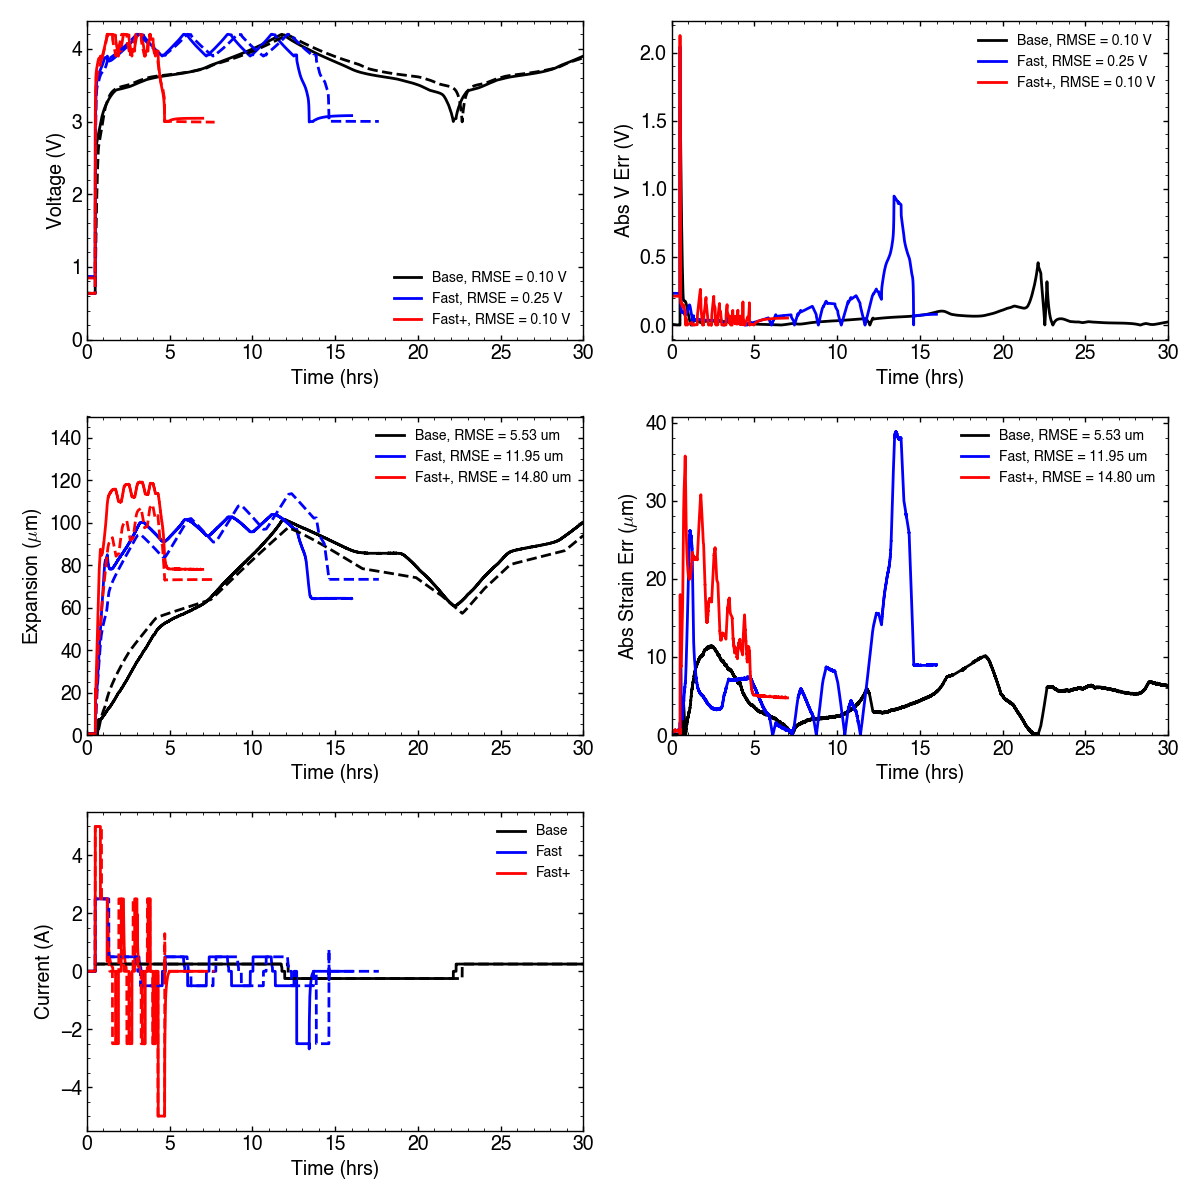

In [8]:
XLIM = (0, 30)
# Beware of experimental vs model data indexing!!
rmse1_v, tv1, sv1 = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
rmse1_e, te1, se1 = calculate_rmse(expt1['daq_time'], expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
rmse2_v, tv2, sv2 = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
rmse2_e, te2, se2 = calculate_rmse(expt3['daq_time'], expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
rmse3_v, tv3, sv3 = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
rmse3_e, te3, se3 = calculate_rmse(expt4['daq_time'], expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)


fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Voltage plot
ax = axes[0, 0]
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label=f'Base, RMSE = {rmse1_v:.2f} V')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# Voltage error plot
ax = axes[0, 1]
ax.plot(tv1/3600, sv1, color='k', label=f'Base, RMSE = {rmse1_v:.2f} V')
ax.plot(tv2/3600, sv2, color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V')
ax.plot(tv3/3600, sv3, color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Abs V Err (V)')
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# Expansion plot
ax = axes[1, 0]
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion'])*1e6, color='r', ls='--', label='')
ax.legend(fontsize=10)
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlabel('Time (hrs)')
ax.set_xlim(XLIM)
ax.grid(False)

# Expansion error plot
ax = axes[1, 1]
ax.plot(tv1/3600, se1, color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(tv2/3600, se2, color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(tv3/3600, se3, color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel(r'Abs Strain Err ($\mu$m)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=10)
ax.grid(False)

# Current plot
ax = axes[2, 0]
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend(fontsize=10)
ax.grid(False)
ax.set_xlim(XLIM)

# Empty plot for alignment
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()


# Search for the optimal KAPPA_GAMMA parameter to use for tuning Rsei calculation

In [ ]:
diff_ec = 4.2e-20
diff_vc = 6.6e-18 # For VC

nn = 50
gamma_kappa_vec = np.linspace(0, 5000, nn)

rmse1_e_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
rmse1_v_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
rmse2_e_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
rmse2_v_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
rmse3_e_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
rmse3_v_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
qsei1_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
qsei2_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
qsei3_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
qsei1_vc_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
qsei2_vc_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
qsei3_vc_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
expan1_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
expan2_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
expan3_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
resistance1_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
resistance2_mat = np.zeros((len(gamma_kappa_vec), 1)) * np.nan
resistance3_mat = np.zeros((len(gamma_kappa_vec), 1))

for i, gamma_kappa in enumerate(gamma_kappa_vec):

    print(f'Running simulation with gamma_kappa = {gamma_kappa:.2f}')

    try:
        df_sim1 = run_sim('base', diff_ec, diff_vc, gamma_kappa)
        df_sim2 = run_sim('fast', diff_ec, diff_vc, gamma_kappa)
        df_sim3 = run_sim('fast+', diff_ec, diff_vc, gamma_kappa)
    except:
        continue

    # Extract the qsei values:
    qsei1_mat[i, 0] = df_sim1['q_sei'].iloc[-1]
    qsei2_mat[i, 0] = df_sim2['q_sei'].iloc[-1]
    qsei3_mat[i, 0] = df_sim3['q_sei'].iloc[-1]

    qsei1_vc_mat[i, 0] = df_sim1['q_sei2'].iloc[-1]
    qsei2_vc_mat[i, 0] = df_sim2['q_sei2'].iloc[-1]
    qsei3_vc_mat[i, 0] = df_sim3['q_sei2'].iloc[-1]

    # Extract the expansion values:
    expan1_mat[i, 0] = df_sim1['expansion'].iloc[-1]
    expan2_mat[i, 0] = df_sim2['expansion'].iloc[-1]
    expan3_mat[i, 0] = df_sim3['expansion'].iloc[-1]

    # Extract the resistance values:
    resistance1_mat[i, 0] = df_sim1['R_sei'].iloc[-1]
    resistance2_mat[i, 0] = df_sim2['R_sei'].iloc[-1]
    resistance3_mat[i, 0] = df_sim3['R_sei'].iloc[-1]

    # Beware of experimental vs model data indexing!!
    rmse1_v, _, _ = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
    rmse1_e, _, _ = calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
    rmse2_v, _, _ = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
    rmse2_e, _, _ = calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
    rmse3_v, _, _ = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
    rmse3_e, _, _ = calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

    rmse1_e_mat[i, 0] = rmse1_e
    rmse1_v_mat[i, 0] = rmse1_v
    rmse2_e_mat[i, 0] = rmse2_e
    rmse2_v_mat[i, 0] = rmse2_v
    rmse3_e_mat[i, 0] = rmse3_e
    rmse3_v_mat[i, 0] = rmse3_v

Running simulation with gamma_kappa = 0.00
Running Cyc1: Rest for 0.5 hours...
Running simulation with gamma_kappa = 102.04
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...


/Users/ampere/code/formation-modeling/src/cellsim.py:156: RuntimeWarning: divide by zero encountered in scalar divide
  self.delta_sei1[0] /
/Users/ampere/code/formation-modeling/src/cellsim.py:161: RuntimeWarning: divide by zero encountered in scalar divide
  self.delta_sei2[0] /
/Users/ampere/code/formation-modeling/src/cellsim.py:229: RuntimeWarning: invalid value encountered in scalar multiply
  self.eta_n[k+1] = p.R1n * self.i_r1n[k] + self.R_sei[k] * self.i_int[k]


Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running Cyc

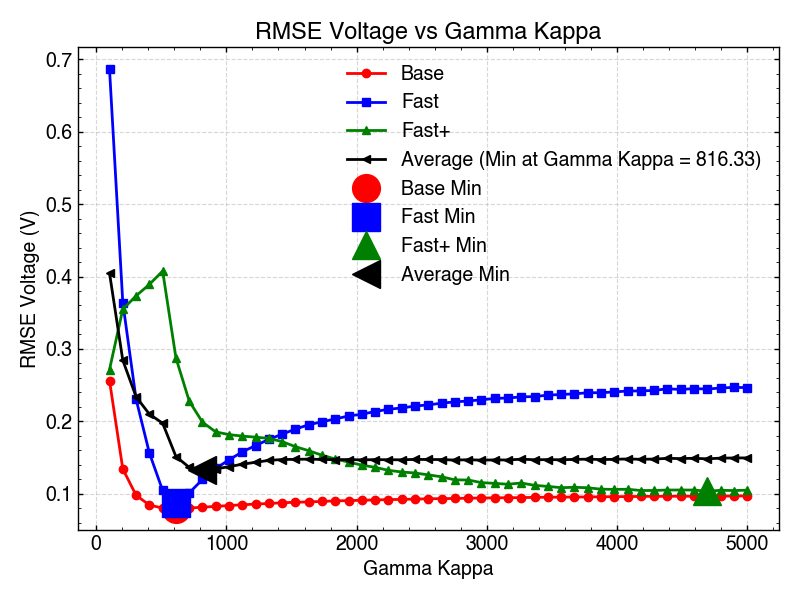

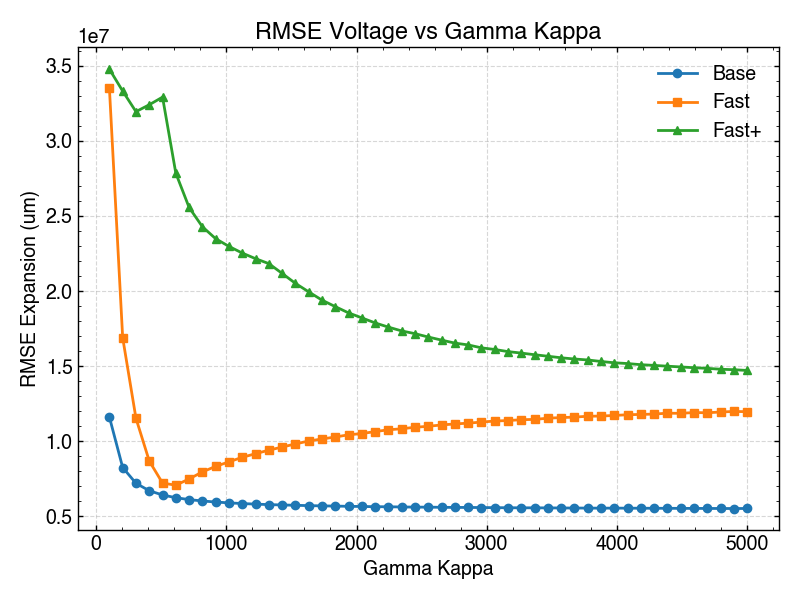

In [74]:
rmse1_v_mat = rmse1_v_mat.flatten()
rmse1_e_mat = rmse1_e_mat.flatten()
rmse2_v_mat = rmse2_v_mat.flatten()
rmse2_e_mat = rmse2_e_mat.flatten()
rmse3_v_mat = rmse3_v_mat.flatten()
rmse3_e_mat = rmse3_e_mat.flatten()

rmse = (rmse1_v_mat + rmse2_v_mat + rmse3_v_mat)/3

plt.figure(figsize=(8, 6))
plt.plot(gamma_kappa_vec, rmse1_v_mat, label='Base', marker='o', c='r')
plt.plot(gamma_kappa_vec, rmse2_v_mat, label='Fast', marker='s', c='b')
plt.plot(gamma_kappa_vec, rmse3_v_mat, label='Fast+', marker='^', c='g')
plt.plot(gamma_kappa_vec, rmse, label=f'Average (Min at Gamma Kappa = {gamma_kappa_vec[np.nanargmin(rmse)]:.2f})', marker='<', c='k')
plt.plot(gamma_kappa_vec[np.nanargmin(rmse1_v_mat)], np.nanmin(rmse1_v_mat), 'ro', markersize=20, label='Base Min')
plt.plot(gamma_kappa_vec[np.nanargmin(rmse2_v_mat)], np.nanmin(rmse2_v_mat), 'bs', markersize=20, label='Fast Min')
plt.plot(gamma_kappa_vec[np.nanargmin(rmse3_v_mat)], np.nanmin(rmse3_v_mat), 'g^', markersize=20, label='Fast+ Min')
plt.plot(gamma_kappa_vec[np.nanargmin(rmse)], np.nanmin(rmse), 'k<', markersize=20, label='Average Min')
plt.xlabel('Gamma Kappa')
plt.ylabel('RMSE Voltage (V)')
plt.title('RMSE Voltage vs Gamma Kappa')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


plt.figure(figsize=(8, 6))
plt.plot(gamma_kappa_vec, rmse1_e_mat*1e6, label='Base', marker='o')
plt.plot(gamma_kappa_vec, rmse2_e_mat*1e6, label='Fast', marker='s')
plt.plot(gamma_kappa_vec, rmse3_e_mat*1e6, label='Fast+', marker='^')
plt.xlabel('Gamma Kappa')
plt.ylabel('RMSE Expansion (um)')
plt.title('RMSE Voltage vs Gamma Kappa')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [9]:
print(df_sim1['q_sei'].iloc[-1])
print(df_sim2['q_sei'].iloc[-1])
print(df_sim3['q_sei'].iloc[-1])

0.3330956580965104
0.27470730031515755
0.26246172486567537


In [10]:
print(df_sim1['R_sei'].iloc[-1])

0.030904721646718307


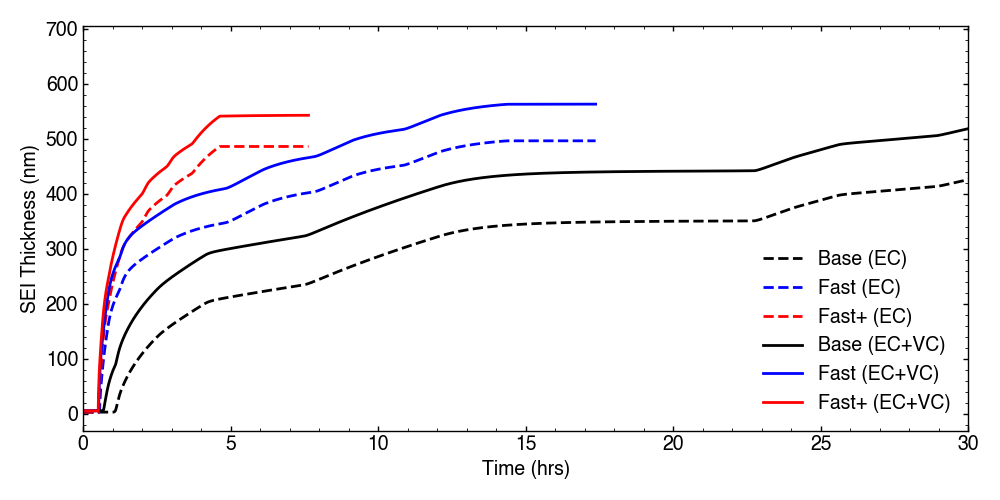

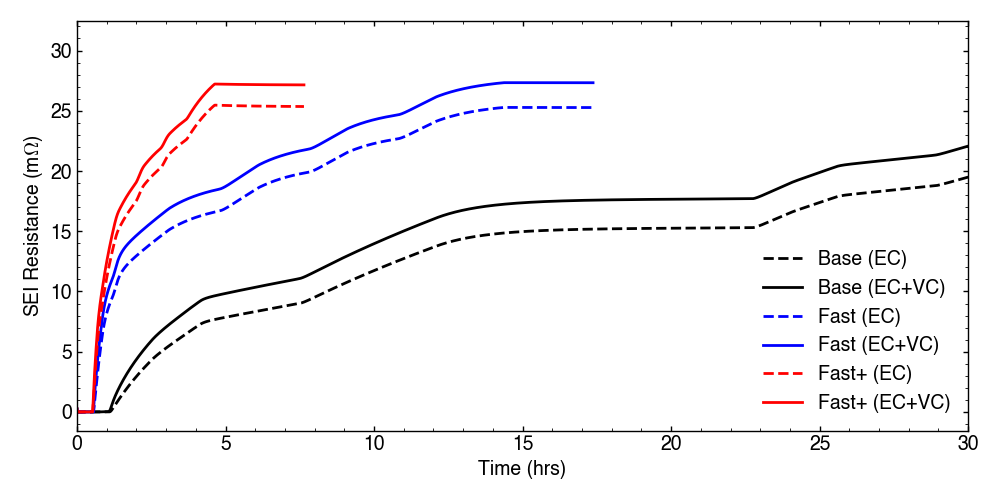

In [11]:
plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['delta_sei1']*1e9, color='k', ls='--', label='Base (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['delta_sei1']*1e9, ls='--', color='b', label='Fast (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['delta_sei1']*1e9, ls='--', color='r', label='Fast+ (EC)')
ax4.plot(df_sim1['t']/3600, (df_sim1['delta_sei'])*1e9, color='k', ls='-', label='Base (EC+VC)')
ax4.plot(df_sim2['t']/3600, (df_sim2['delta_sei'])*1e9, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, (df_sim3['delta_sei'])*1e9, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel('SEI Thickness (nm)')
ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)
ax2 = plt.gca()


plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei1']*1000, color='k', label='Base (EC)', ls='--')
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei']*1000, color='k', label='Base (EC+VC)', ls='-')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei1']*1000, color='b', ls='--', label='Fast (EC)')
ax4.plot(df_sim2['t']/3600, df_sim2['R_sei']*1000, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei1']*1000, color='r', ls='--', label='Fast+ (EC)')
ax4.plot(df_sim3['t']/3600, df_sim3['R_sei']*1000, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel(r'SEI Resistance (m$\Omega$)')

ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)

In [12]:
# Create a table comparing SEI growth across different protocols
df_result = pd.DataFrame()

# Create column headers for different time points
time_points = ['2 hrs', 'After Formation Cycles']

protocols = []
total_sei = []
vc_pcts = []
D_sei1 = []
D_sei2 = []

 # Base formation (sim1)
for t in [2*3600, sim1_time1*3600]:
    q_sei = df_sim1[df_sim1['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim1[df_sim1['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Base')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim1[df_sim1['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim1[df_sim1['t'] <= t]['D_sei2'].iloc[-1])

# Fast formation (sim2)
for t in [2*3600, sim2_time1*3600]:
    q_sei = df_sim2[df_sim2['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim2[df_sim2['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim2[df_sim2['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim2[df_sim2['t'] <= t]['D_sei2'].iloc[-1])

# Fast+ formation (sim3)
for t in [2*3600, sim3_time1*3600]:
    q_sei = df_sim3[df_sim3['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim3[df_sim3['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast+')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim3[df_sim3['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim3[df_sim3['t'] <= t]['D_sei2'].iloc[-1])


df_result = pd.DataFrame({
    'Protocol': protocols,
    'Time Point': time_points * 3,
    'Total SEI (Ah)': total_sei,
    'VC SEI %': vc_pcts,
    'D_sei1': D_sei1,
    'D_sei2': D_sei2
})


print(df_result.to_string(index=False))

Protocol             Time Point  Total SEI (Ah)  VC SEI %       D_sei1       D_sei2
    Base                  2 hrs        0.111792 56.429456 9.560743e-20 9.560743e-20
    Base After Formation Cycles        0.333096 21.173526 5.319067e-20 5.319067e-20
    Fast                  2 hrs        0.171437 25.521232 5.626921e-20 5.626921e-20
    Fast After Formation Cycles        0.274707 17.664453 5.094123e-20 5.094123e-20
   Fast+                  2 hrs        0.195224 18.709636 5.159108e-20 5.159108e-20
   Fast+ After Formation Cycles        0.262462 15.620271 4.971642e-20 4.971642e-20


In [ ]:
nn = 25
diff_ec_vec = np.logspace(-21, -18, nn)
diff_vc_vec = np.logspace(-20, -13, nn)

rmse1_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse1_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

expan1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

resistance1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
resistance2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))   
resistance3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

gamma_kappa = 4800

for i, diff_ec in enumerate(diff_ec_vec):
    for j, diff_vc in enumerate(diff_vc_vec):

        print(f'Running simulation with D_EC = {diff_ec:.2e} m2/s and D_VC = {diff_vc:.2e} m2/s')

        try:
            df_sim1 = run_sim('base', diff_ec, diff_vc, gamma_kappa)
            df_sim2 = run_sim('fast', diff_ec, diff_vc, gamma_kappa)
            df_sim3 = run_sim('fast+', diff_ec, diff_vc, gamma_kappa)
        except:
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
        rmse1_e, _, _ = calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
        rmse2_v, _, _ = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
        rmse2_e, _, _ = calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
        rmse3_v, _, _ = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
        rmse3_e, _, _ = calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

Running simulation with D_EC = 1.00e-21 m2/s and D_VC = 1.00e-20 m2/s
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hou

/Users/ampere/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: overflow encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: overflow encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.0V...


/Users/ampere/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: overflow encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running Cyc6: Rest for 3 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc6: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running simulation with D_EC = 7.50e-19 m2/s and D_VC = 1.00e-20 m2/s
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running

/Users/ampere/code/formation-modeling/src/cellsim.py:274: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:275: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])


Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc6: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running simulation with D_EC = 1.00e-18 m2/s and D_VC = 1.00e-20 m2/s
Running Cyc1: Rest for 0.5 hours...
Runn

# Create a scatterplot of expansion, capacity, and resistance, for all simulated combinations of {DSEI1, DSEI2}

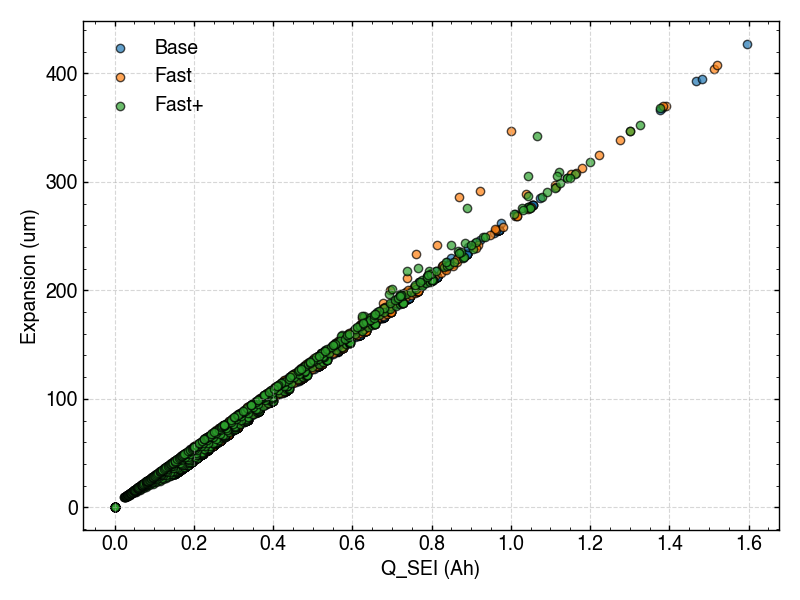

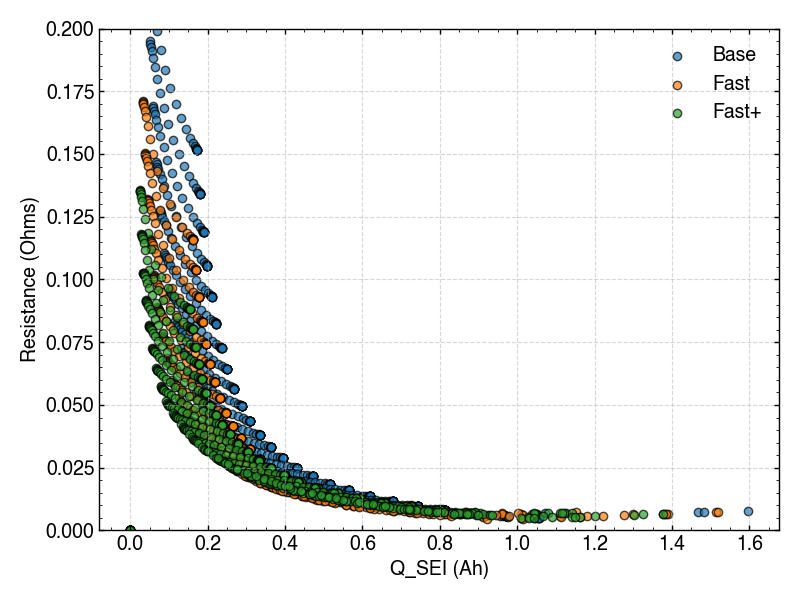

In [14]:
qsei1_flat = qsei1_mat.flatten()
qsei2_flat = qsei2_mat.flatten()
qsei3_flat = qsei3_mat.flatten()

expan1_flat = expan1_mat.flatten()
expan2_flat = expan2_mat.flatten()
expan3_flat = expan3_mat.flatten()

resistance1_flat = resistance1_mat.flatten()
resistance2_flat = resistance2_mat.flatten()
resistance3_flat = resistance3_mat.flatten()

plt.figure(figsize=(8, 6))
plt.scatter(qsei1_flat, expan1_flat*1e6, alpha=0.7, edgecolors='k', label='Base')
plt.scatter(qsei2_flat, expan2_flat*1e6, alpha=0.7, edgecolors='k', label='Fast')
plt.scatter(qsei3_flat, expan3_flat*1e6, alpha=0.7, edgecolors='k', label='Fast+')
plt.xlabel('Q_SEI (Ah)')
plt.ylabel('Expansion (um)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(qsei1_flat, resistance1_flat, alpha=0.7, edgecolors='k', label='Base')
plt.scatter(qsei2_flat, resistance2_flat, alpha=0.7, edgecolors='k', label='Fast')
plt.scatter(qsei3_flat, resistance3_flat, alpha=0.7, edgecolors='k', label='Fast+')
plt.xlabel('Q_SEI (Ah)')
plt.ylabel('Resistance (Ohms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.ylim((0, 0.2))
plt.show()

# Prepare data for plotting {DSEI, DSEI2} heatmaps

In [15]:
# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

<>:59: SyntaxWarning: invalid escape sequence '\h'
<>:60: SyntaxWarning: invalid escape sequence '\h'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:59: SyntaxWarning: invalid escape sequence '\h'
<>:60: SyntaxWarning: invalid escape sequence '\h'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_50310/1214986408.py:59: SyntaxWarning: invalid escape sequence '\h'
  plot_diffusivity_heatmaps(eq1_mat, eq2_mat, eq3_mat, '$E_Q = (Q-\hat{Q})^2$', zmin=0, zmax=0.2)
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_50310/1214986408.py:60: SyntaxWarning: invalid escape sequence '\h'
  plot_diffusivity_heatmaps(er1_mat, er2_mat, er3_mat, '$E_R = (R-\hat{R})^2$', zmin=0, zmax=0.1)
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_50310/1214986408.py:63: SyntaxWarning: invalid escape sequence '\e'
  plot_diffusiv

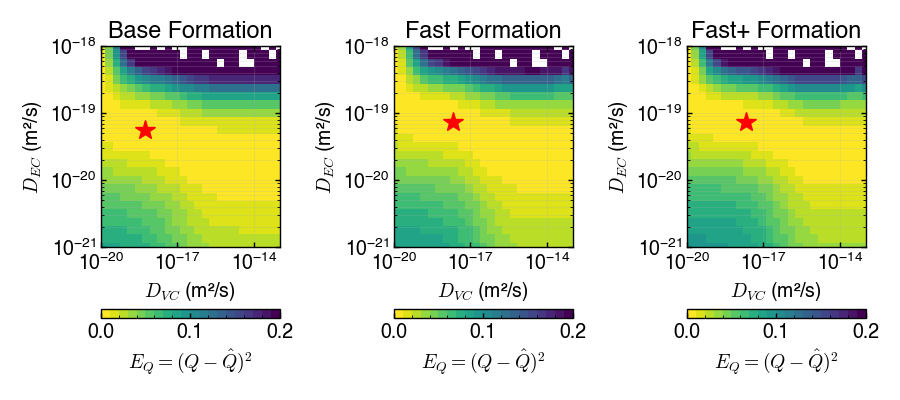

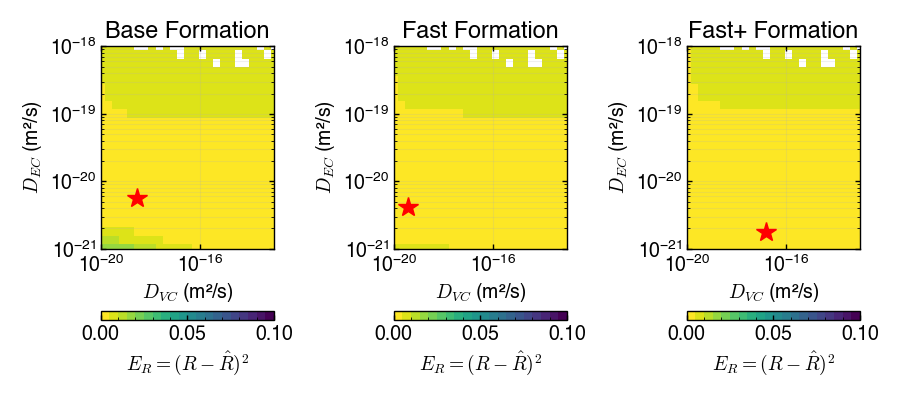

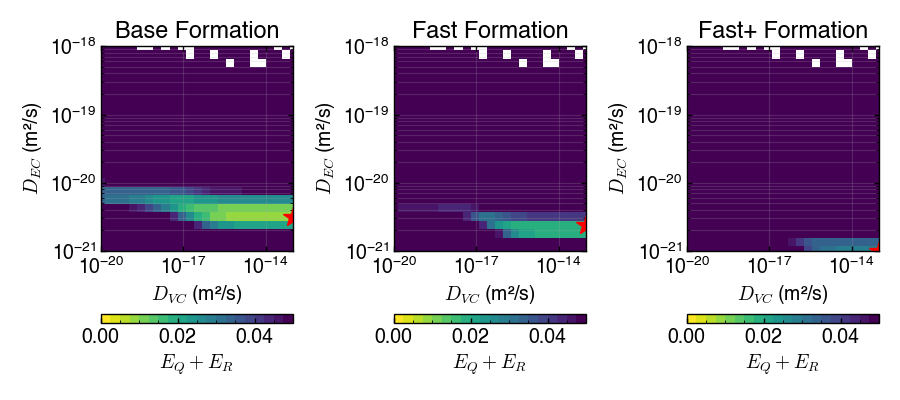

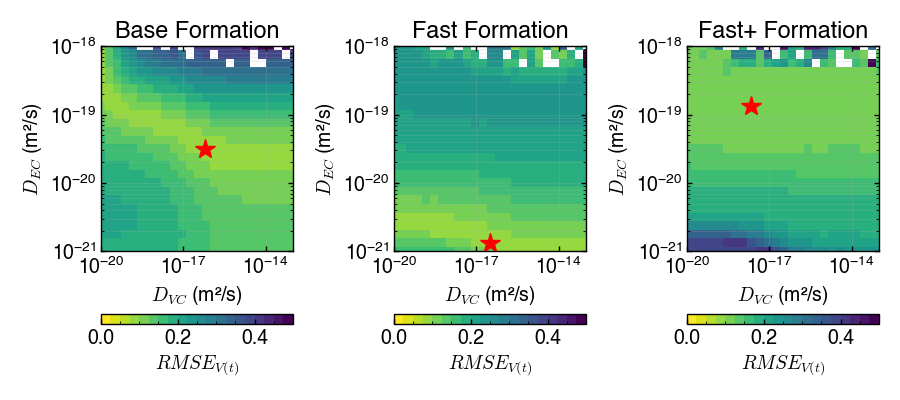

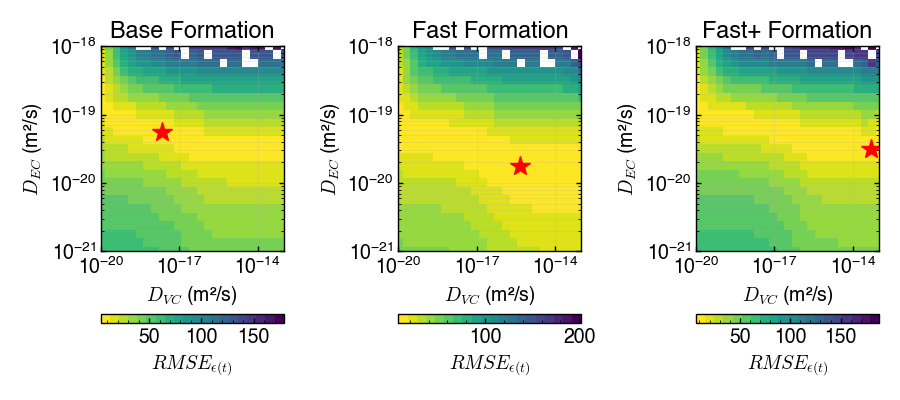

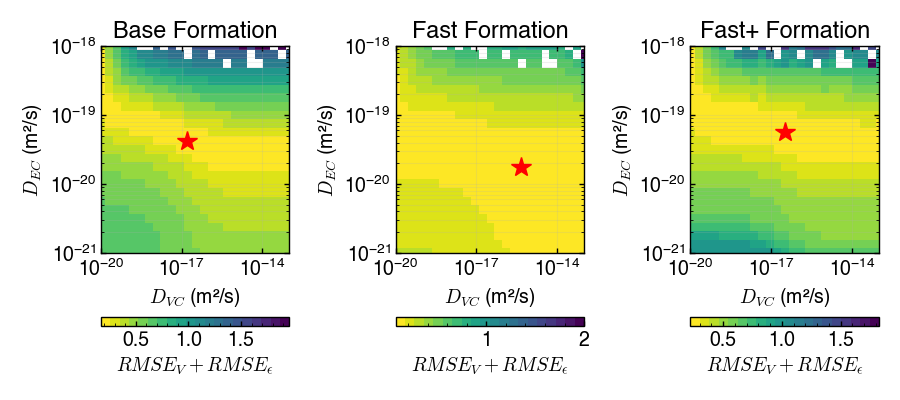

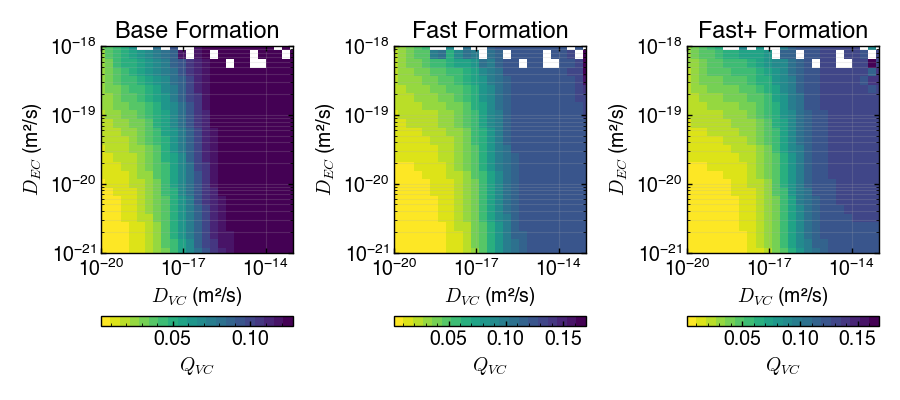

In [28]:
def plot_diffusivity_heatmaps(mat1, mat2, mat3, label, is_error_plot=True, 
                              zmin=None, zmax=None):

    nn = 25
    diff_ec_vec = np.logspace(-21, -18, nn)
    diff_vc_vec = np.logspace(-20, -13, nn)

#  Create a meshgrid for X and Y axes
    X, Y = np.meshgrid(diff_vc_vec, diff_ec_vec)

# Create subplots for the three formation protocols
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 4))
    [ax.set_xlim([min(diff_vc_vec), max(diff_vc_vec)]) for ax in (ax1, ax2, ax3)]
    [ax.set_ylim([min(diff_ec_vec), max(diff_ec_vec)]) for ax in (ax1, ax2, ax3)]
    [ax.set_xscale('log') for ax in (ax1, ax2, ax3)]
    [ax.set_yscale('log') for ax in (ax1, ax2, ax3)]
    [ax.set_xlabel('$D_{VC}$ (m²/s)') for ax in (ax1, ax2, ax3)]
    [ax.set_ylabel('$D_{EC}$ (m²/s)') for ax in (ax1, ax2, ax3)]
    [ax.grid(True, which="both", ls="-", alpha=0.2) for ax in (ax1, ax2, ax3)]
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

# Get the colormap and create a discrete version with 10 bins
    cmap = cm.get_cmap('viridis_r', 20)

# Base Formation
    pcm1 = ax1.pcolormesh(X, Y, mat1, shading='auto', cmap=cmap)
    vmin, vmax = np.nanmin(mat1), np.nanmax(mat1)
    plt.colorbar(pcm1, ax=ax1, label=label, orientation='horizontal', pad=0.2)
    pcm1.set_clim(zmin, zmax)
    i, j = np.unravel_index(np.nanargmin(mat1), mat1.shape)
    ax1.set_title('Base Formation')

# Fast Formation
    pcm2 = ax2.pcolormesh(X, Y, mat2, shading='auto', cmap=cmap)
    plt.colorbar(pcm2, ax=ax2, label=label, orientation='horizontal', pad=0.2)
    pcm2.set_clim(zmin, zmax)
    ax2.set_title('Fast Formation')

# Fast+ Formation
    pcm3 = ax3.pcolormesh(X, Y, mat3, shading='auto', cmap=cmap)
    plt.colorbar(pcm3, ax=ax3, label=label, orientation='horizontal', pad=0.2)
    pcm3.set_clim(zmin, zmax)
    ax3.set_title('Fast+ Formation')

    if is_error_plot:
        i, j = np.unravel_index(np.nanargmin(mat1), mat1.shape)
        ax1.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
             label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
        i, j = np.unravel_index(np.nanargmin(mat2), mat2.shape)
        ax2.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
             label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')
        i, j = np.unravel_index(np.nanargmin(mat3), mat3.shape)
        ax3.plot(diff_vc_vec[j], diff_ec_vec[i], 'r*', markersize=15,
             label=f'Min RMSE at\nD_EC={diff_ec_vec[i]:.2e}\nD_VC={diff_vc_vec[j]:.2e}')

    plt.tight_layout()

plot_diffusivity_heatmaps(eq1_mat, eq2_mat, eq3_mat, '$E_Q = (Q-\hat{Q})^2$', zmin=0, zmax=0.2)
plot_diffusivity_heatmaps(er1_mat, er2_mat, er3_mat, '$E_R = (R-\hat{R})^2$', zmin=0, zmax=0.1)
plot_diffusivity_heatmaps(ec1_mat, ec2_mat, ec3_mat, '$E_Q + E_R$', zmin=0.0, zmax=0.05)
plot_diffusivity_heatmaps(rmse1_v_mat, rmse2_v_mat, rmse3_v_mat, '$RMSE_{V(t)}$', zmin=0, zmax=0.5)
plot_diffusivity_heatmaps(rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, '$RMSE_{\epsilon(t)}$')
plot_diffusivity_heatmaps(combined_rmse1, combined_rmse2, combined_rmse3, '$RMSE_V + RMSE_{\epsilon}$')
plot_diffusivity_heatmaps(qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat, '$Q_{VC}$', is_error_plot=False)

# Re-run the simulations using optimal Dsei

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.

(0.0, 30.0)

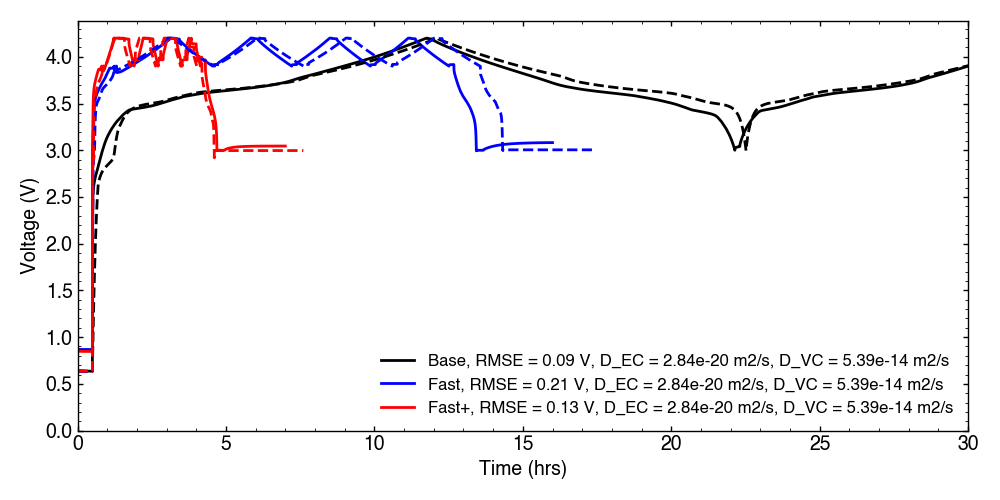

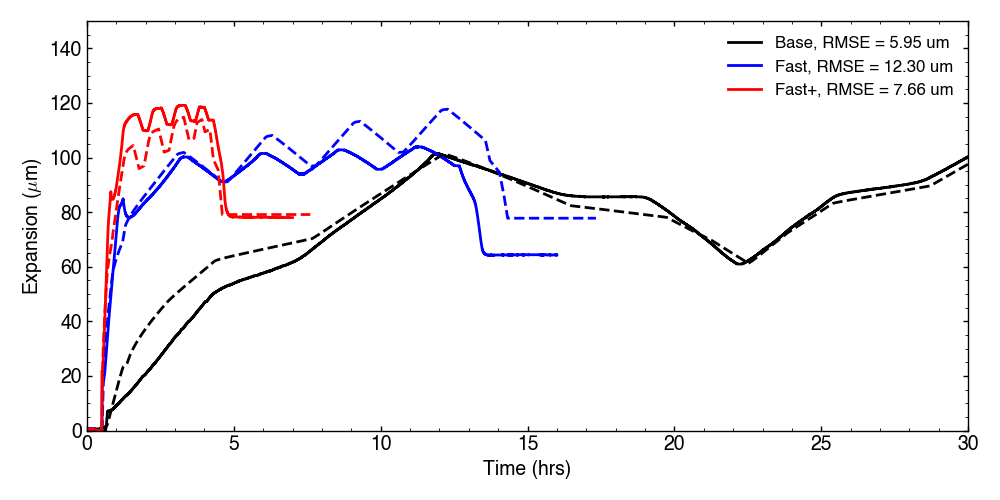

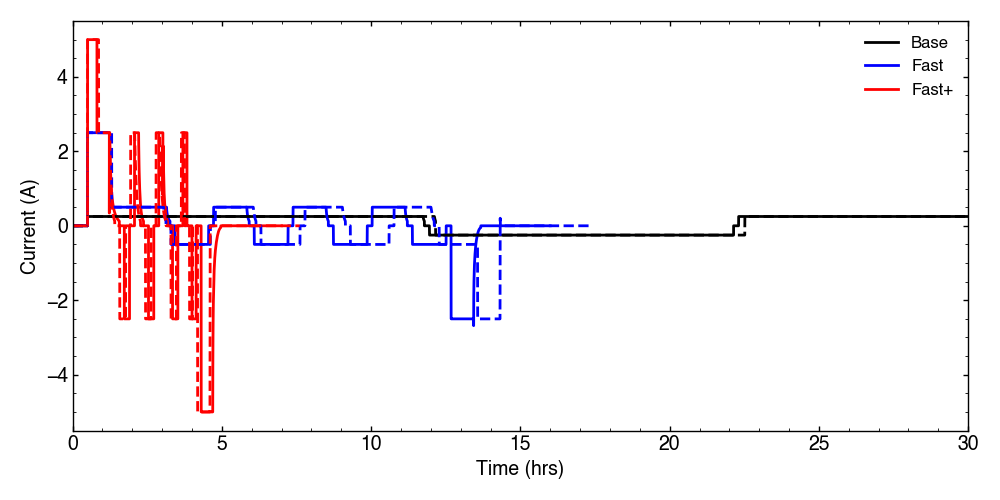

In [ ]:
d_ec_opt = 2.84e-20
d_vc_opt = 5.39e-14
gamma_kappa = 4800

df_sim1 = run_sim('base', d_ec_opt, d_vc_opt, gamma_kappa)
df_sim2 = run_sim('fast', d_ec_opt, d_vc_opt, gamma_kappa)
df_sim3 = run_sim('fast+', d_ec_opt, d_vc_opt, gamma_kappa)

XLIM = (0, 30)

rmse1_v, _, _ = calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
rmse1_e, _, _ = calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
rmse2_v, _, _ = calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
rmse2_e, _, _ = calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
rmse3_v, _, _ = calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
rmse3_e, _, _ = calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

# The voltage plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label=f'Base, RMSE = {rmse1_v:.2f} V, D_EC = {d_ec_opt:.2e} m2/s, D_VC = {d_vc_opt:.2e} m2/s')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label=f'Fast, RMSE = {rmse2_v:.2f} V, D_EC = {d_ec_opt:.2e} m2/s, D_VC = {d_vc_opt:.2e} m2/s')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label=f'Fast+, RMSE = {rmse3_v:.2f} V, D_EC = {d_ec_opt:.2e} m2/s, D_VC = {d_vc_opt:.2e} m2/s')
ax.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['vt'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Voltage (V)')
ax.set_ylim(bottom=0)
ax.set_xlim(XLIM)
ax.legend(fontsize=12)
ax.grid(False)

# The expansion plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label=f'Base, RMSE = {rmse1_e:.2f} um')
ax.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label=f'Fast, RMSE = {rmse2_e:.2f} um')
ax.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label=f'Fast+, RMSE = {rmse3_e:.2f} um')
ax.plot(df_sim1['t']/3600, (df_sim1['expansion'])*1e6, color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, (df_sim2['expansion'])*1e6, color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, (df_sim3['expansion'])*1e6, color='r', ls='--', label='')
ax.legend(fontsize=12)
ax.set_ylabel(r'Expansion ($\mu$m)')
ax.set_ylim(bottom=0, top=150)
ax.set_xlabel('Time (hrs)')
ax.set_xlim(XLIM)
ax.grid(False)

# The current plot
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax.plot(df_sim2['t']/3600, df_sim2['i_app'], color='b', ls='--', label='')
ax.plot(df_sim3['t']/3600, df_sim3['i_app'], color='r', ls='--', label='')
ax.set_xlabel('Time (hrs)')
ax.set_ylabel('Current (A)')
ax.legend(fontsize=12)
ax.grid(False)
ax.set_xlim(XLIM)